# 📄 CV-Agent Preprocessing & Analysis

This notebook performs preprocessing and analysis for the CV-Agent system.

## 🎯 Objective
To:
- Load resumes and job descriptions
- Clean and preprocess text data
- Perform exploratory data analysis
- Apply vectorization
- Compute similarity scores
- Visualize results


 # (Install Libraries)

In [1]:
!pip install PyPDF2 nltk scikit-learn matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# 📂 Step 1: Load Data

We load:
- Resume PDF files
- Job description TXT files

In [2]:
import os
import re
import PyPDF2
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

# 1:1 (Load Resumes)

In [9]:
import os
import PyPDF2

def extract_text_from_pdf(file_path):
    text = ""
    
    with open(file_path, "rb") as file:
        reader = PyPDF2.PdfReader(file)

        for page in reader.pages:
            text += page.extract_text()

    return text


cv_texts = []

cv_folder ="Resume_Dataset/data/data"

for root, dirs, files in os.walk(cv_folder):

    for file in files:

        if file.endswith(".pdf"):

            path = os.path.join(root, file)

            text = extract_text_from_pdf(path)

            cv_texts.append(text)

print("Number of CVs:", len(cv_texts))

Number of CVs: 346


# 1:2 (Load Job Descriptions)

In [14]:
job_texts = []
job_folder = "Job_description_dataset/cs"

for root, dirs, files in os.walk(job_folder):
    for file in files:
        if file.endswith(".txt"):
            path = os.path.join(root, file)
            with open(path, "r", encoding="utf-8") as f:
                job_texts.append(f.read())

print("Number of job descriptions loaded:", len(job_texts))

Number of job descriptions loaded: 7


# STEP 2 : 📄 Sample Dataset Overview

This section displays sample resume files and their corresponding job descriptions from different categories in the dataset.

The purpose of this section is to:
- Explore the dataset structure
- Visualize sample data
- Understand the relationship between resumes and job descriptions before preprocessing

In [75]:
from IPython.display import IFrame, display
import os

In [81]:
!pip install pymupdf

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/19.2 MB ? eta -:--:--
    --------------------------------------- 0.3/19.2 MB ? eta -:--:--
   -- ------------------------------------- 1.0/19.2 MB 4.2 MB/s eta 0:00:05
   --- ------------------------------------ 1.6/19.2 MB 3.5 MB/s eta 0:00:06
   ---- ----------------------------------- 2.4/19.2 MB 3.7 MB/s eta 0:00:05
   ------- -------------------------------- 3.4/19.2 MB 4.0 MB/s eta 0:00:04
   --------- ------------------------------ 4.5/19.2 MB 4.2 MB/s eta 0:00:04
   ----------- ---------------------------- 5.8/19.2 MB 4.5 MB/s eta 0:00:03
   -------------- ------------------------- 7.1/19.2 MB 4.8 MB/s eta 0:00:03
   ----------------- ---------------------- 8.7/19.2 MB 5.0 MB/s eta 0:00:03
   -------------------- ------------------- 10.0/19.2 MB 5.2 MB/s eta 0:00:02
   ----------------------- ---------------- 11.3/19.2 MB 5.3 MB/s eta 0:00:02
   -------


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



Category: ACCOUNTANT



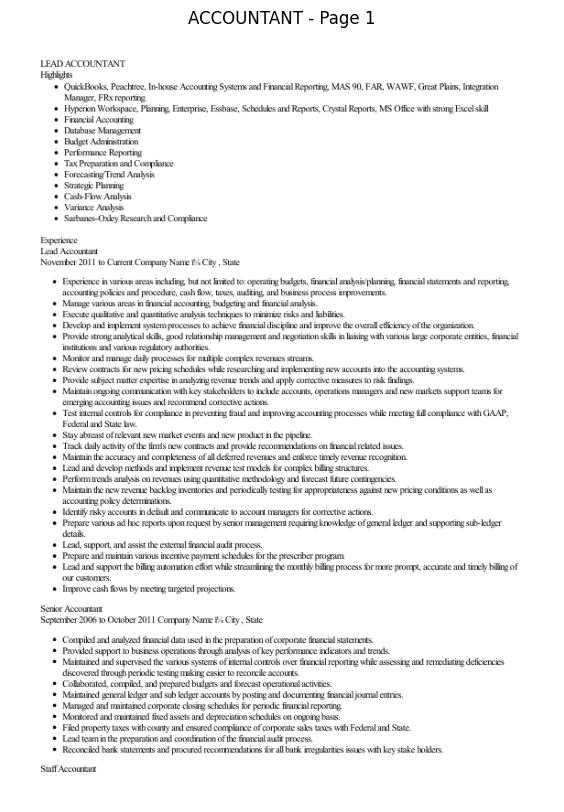

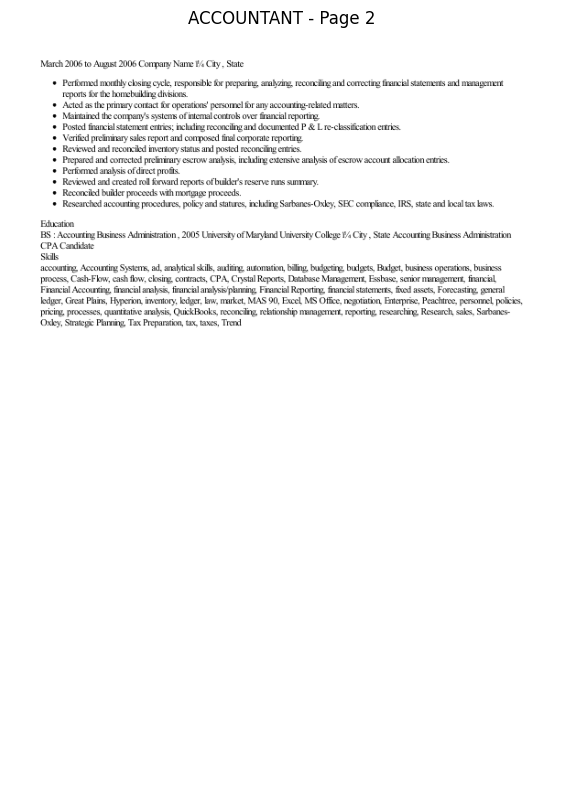


Category:  ACCOUNTANT



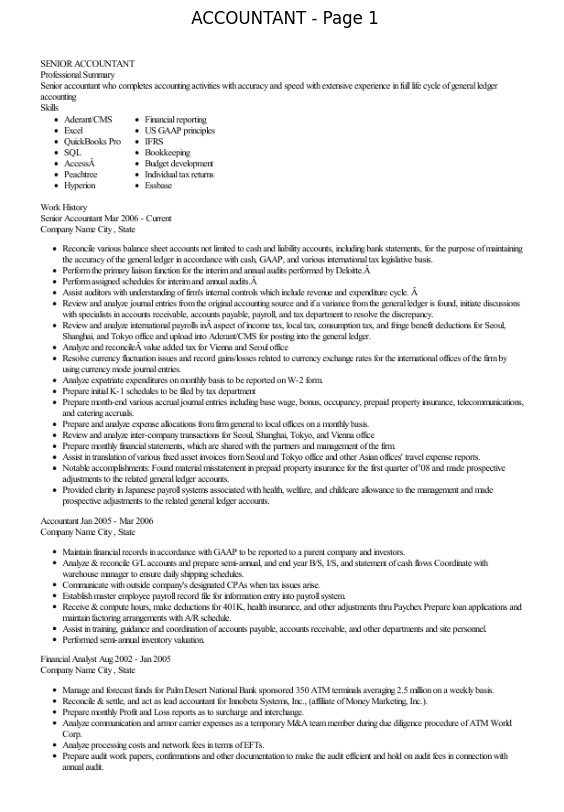

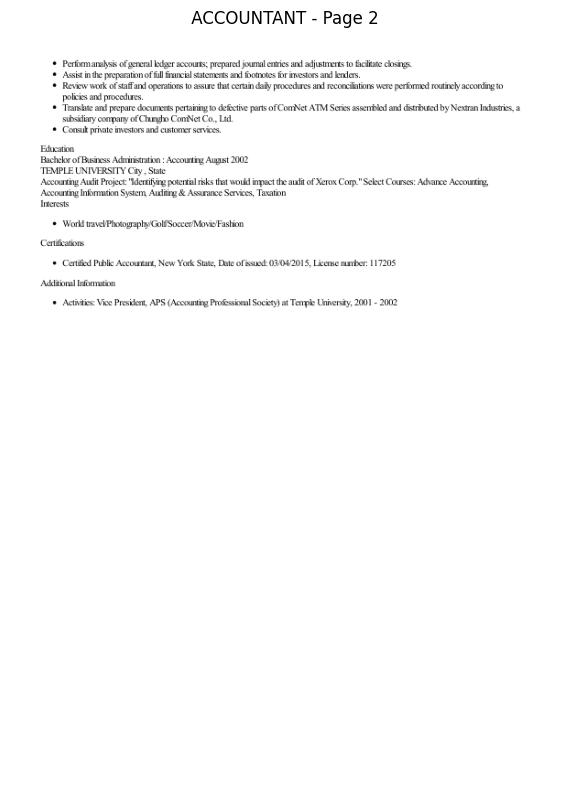

In [91]:
import fitz
import matplotlib.pyplot as plt
import numpy as np

sample_resumes = {

    "ACCOUNTANT": "Resume_Dataset/data/data/ACCOUNTANT/10554236.pdf",

    "ACCOUNTANT": "Resume_Dataset/data/data/ACCOUNTANT/13701259.pdf",

    " ACCOUNTANT": "Resume_Dataset/data/data/ACCOUNTANT/12065211.pdf",

    "ACCOUNTANT": "Resume_Dataset/data/data/ACCOUNTANT/12802330.pdf"
}

for category, pdf_path in sample_resumes.items():

    print("\n========================================")
    print(f"Category: {category}")
    print("========================================\n")

    pdf_document = fitz.open(pdf_path)

    for page_number in range(len(pdf_document)):

        page = pdf_document[page_number]

        pix = page.get_pixmap()

        img = np.frombuffer(
            pix.samples,
            dtype=np.uint8
        ).reshape(pix.height, pix.width, pix.n)

        plt.figure(figsize=(8,10))

        plt.imshow(img)

        plt.axis("off")

        plt.title(f"{category} - Page {page_number + 1}")

        plt.show()


Category: HR



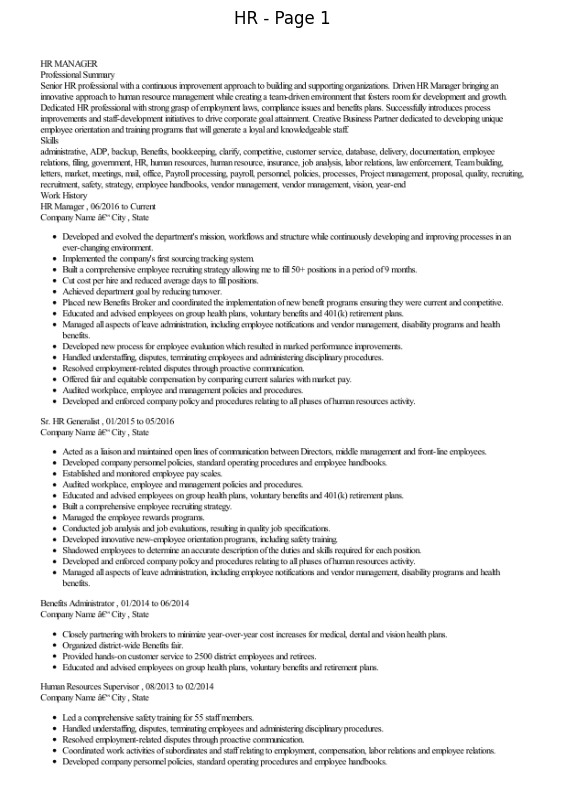

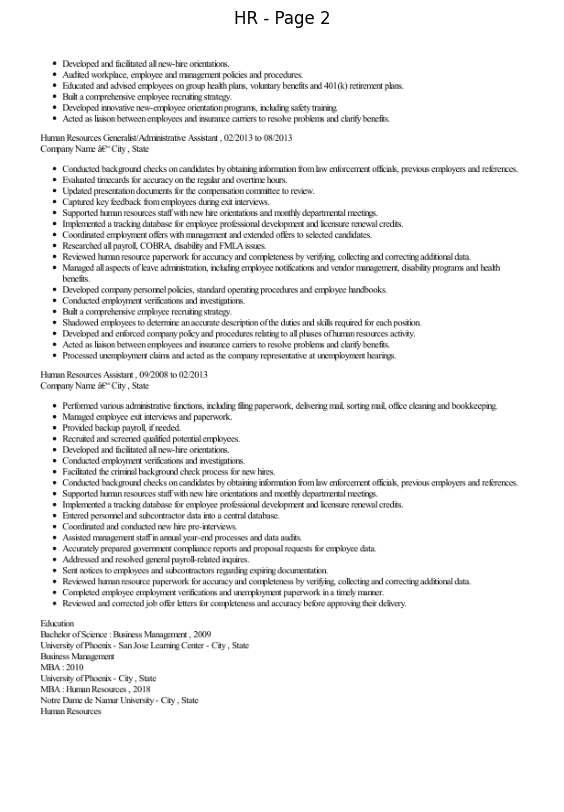

In [90]:
import fitz
import matplotlib.pyplot as plt
import numpy as np

sample_resumes = {

    "HR": "Resume_Dataset/data/data/HR/10399912.pdf",

    "HR": "Resume_Dataset/data/data/HR/11480899.pdf",

    "HR": "Resume_Dataset/data/data/HR/13376919.pdf",

    "HR": "Resume_Dataset/data/data/HR/15375009.pdf",
}

for category, pdf_path in sample_resumes.items():

    print("\n========================================")
    print(f"Category: {category}")
    print("========================================\n")

    pdf_document = fitz.open(pdf_path)

    for page_number in range(len(pdf_document)):

        page = pdf_document[page_number]

        pix = page.get_pixmap()

        img = np.frombuffer(
            pix.samples,
            dtype=np.uint8
        ).reshape(pix.height, pix.width, pix.n)

        plt.figure(figsize=(8,10))

        plt.imshow(img)

        plt.axis("off")

        plt.title(f"{category} - Page {page_number + 1}")

        plt.show()


Category: TEACHER



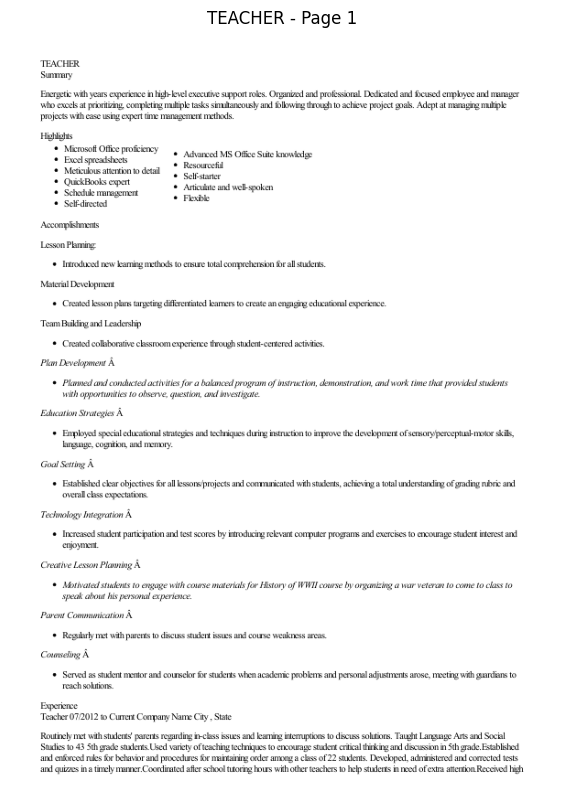

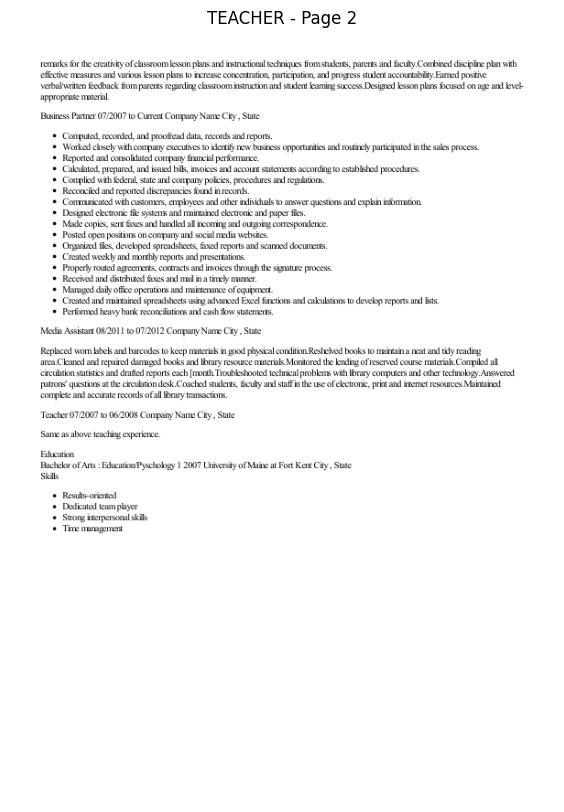

In [92]:
import fitz
import matplotlib.pyplot as plt
import numpy as np

sample_resumes = {

    "TEACHER": "Resume_Dataset/data/data/TEACHER/19918523.pdf",

    "TEACHER": "Resume_Dataset/data/data/TEACHER/19464810.pdf",

    "TEACHER": "Resume_Dataset/data/data/TEACHER/20230207.pdf",

    "TEACHER": "Resume_Dataset/data/data/TEACHER/22551979.pdf",
}

for category, pdf_path in sample_resumes.items():

    print("\n========================================")
    print(f"Category: {category}")
    print("========================================\n")

    pdf_document = fitz.open(pdf_path)

    for page_number in range(len(pdf_document)):

        page = pdf_document[page_number]

        pix = page.get_pixmap()

        img = np.frombuffer(
            pix.samples,
            dtype=np.uint8
        ).reshape(pix.height, pix.width, pix.n)

        plt.figure(figsize=(8,10))

        plt.imshow(img)

        plt.axis("off")

        plt.title(f"{category} - Page {page_number + 1}")

        plt.show()

In [79]:
sample_data = {

    "ACCOUNTANT": {
        "resume": "Resume_Dataset/data/data/ACCOUNTANT/10554236.pdf",
        "job": "Job_description_dataset/cs/accountant.txt"
    },

    "HR": {
        "resume": "Resume_Dataset/data/data/HR/12085344.pdf",
        "job": "Job_description_dataset/cs/hr.txt"
    },

    "INFORMATION TECHNOLOGY": {
        "resume": "Resume_Dataset/data/data/INFORMATION-TECHNOLOGY/22324505.pdf",
        "job": "Job_description_dataset/cs/information technology.txt"
    },

    "TEACHER": {
        "resume": "Resume_Dataset/data/data/TEACHER/14584554.pdf",
        "job": "Job_description_dataset/cs/teacher.txt"
    }

}


# STEP 3: Data Preprocessing

# 🧹 Data Preprocessing

In this section, the dataset is prepared for analysis.

The preprocessing pipeline includes:
- Loading job descriptions
- Loading resumes
- Cleaning textual data
- Removing unnecessary characters
- Standardizing text format

In [36]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'\d+', '', text)

    text = re.sub(r'[^\w\s]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

clean_cvs = [clean_text(cv) for cv in cv_texts]

clean_jobs = [clean_text(job) for job in job_texts]

print("Data preprocessing completed successfully.")

Data preprocessing completed successfully.


In [ ]:
import json

data_clean = {
    "clean_cvs": clean_cvs,
    "clean_jobs": clean_jobs
}

with open("../data_cleaned/data_clean.json", "w", encoding="utf-8") as f:
    json.dump(data_clean, f, ensure_ascii=False, indent=2)

print(f"Data saved successfully: {len(clean_cvs)} CVs and {len(clean_jobs)} job descriptions.")

In [18]:
print("Before Cleaning Job:\n")
print(job_texts[0][:1000])

print("\n\nAfter Cleaning Job:\n")
print(clean_jobs[0][:1000])
print(len(clean_cvs))

Before Cleaning Job:

Full job description
Overview
Gain real-world business, accounting, and financial training that will teach you all aspects of financial management pertaining to running a successful business. Our program fully prepares you to become a Controller/VP of Finance of your own financial operation. A key partner in our organization, the Controller/VP of Finance oversees all aspects of financial management and provides balance to the partnership formed with the marketing and operational pieces of our business. As an Accountant, you can count on a career path with a clear beginning and an open end that’s full of opportunities. With training, development, mentoring, and a culture of promotion from within, you’ll always be progressing in your career.

The target compensation for this position is $65,000 annually based on a 40-hour workweek, which includes an hourly rate of $31.25/ hour, plus overtime. For candidates with a master’s degree the target compensation for this pos

# 📊 Exploratory Data Analysis (EDA)

This section analyzes the structure of the dataset.

The analysis includes:
- Resume word count
- Job description word count
- Text distribution visualization

In [39]:
print("Resume Word Counts:\n")

print(cv_lengths)

print("\nJob Description Word Counts:\n")

print(job_lengths)

Resume Word Counts:

[2190, 746, 485, 592, 560, 515, 577, 473, 718, 639, 597, 400, 474, 628, 544, 484, 786, 494, 380, 521, 579, 481, 475, 610, 575, 597, 458, 467, 520, 495, 827, 842, 485, 503, 518, 762, 483, 605, 542, 875, 641, 544, 634, 943, 594, 456, 614, 498, 730, 824, 1267, 187, 621, 642, 500, 523, 2376, 815, 513, 858, 764, 553, 523, 509, 653, 507, 839, 570, 1563, 478, 1036, 702, 483, 1197, 811, 513, 496, 447, 266, 749, 548, 443, 503, 577, 638, 589, 751, 526, 632, 500, 503, 513, 564, 462, 529, 718, 639, 501, 556, 760, 567, 701, 668, 520, 739, 714, 463, 496, 540, 437, 599, 587, 460, 546, 1169, 540, 863, 479, 496, 630, 544, 299, 537, 681, 801, 665, 554, 492, 579, 409, 711, 594, 496, 904, 875, 1224, 289, 607, 488, 606, 496, 482, 843, 527, 582, 666, 475, 774, 936, 583, 399, 1042, 1392, 522, 435, 566, 2032, 925, 461, 921, 528, 834, 542, 1513, 711, 361, 293, 314, 828, 599, 695, 792, 555, 592, 754, 926, 561, 576, 591, 776, 586, 188, 465, 461, 669, 563, 623, 706, 534, 601, 527, 862, 507, 8

In [40]:
print("Average Resume Length:", sum(cv_lengths)/len(cv_lengths))

print("Average Job Description Length:", sum(job_lengths)/len(job_lengths))

Average Resume Length: 612.7312138728323
Average Job Description Length: 285.42857142857144


## STEP 4: 📈 Resume Word Count Distribution

This graph visualizes the distribution of resume lengths based on word count.

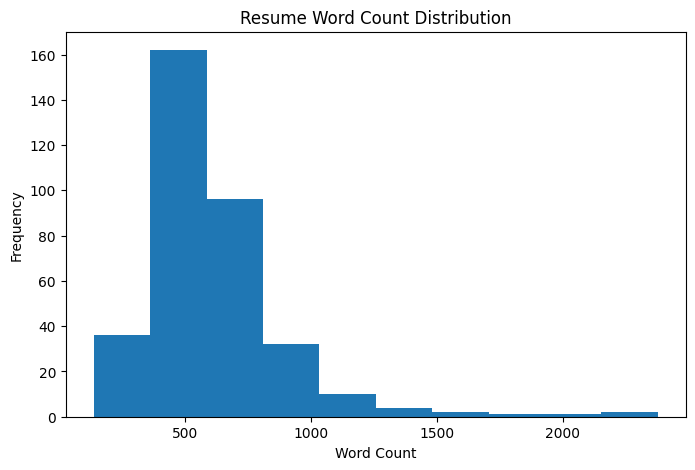

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(cv_lengths)

plt.title("Resume Word Count Distribution")

plt.xlabel("Word Count")

plt.ylabel("Frequency")

plt.show()

## 4:1 📈 Job Description Word Count Distribution

This graph visualizes the distribution of job description lengths.

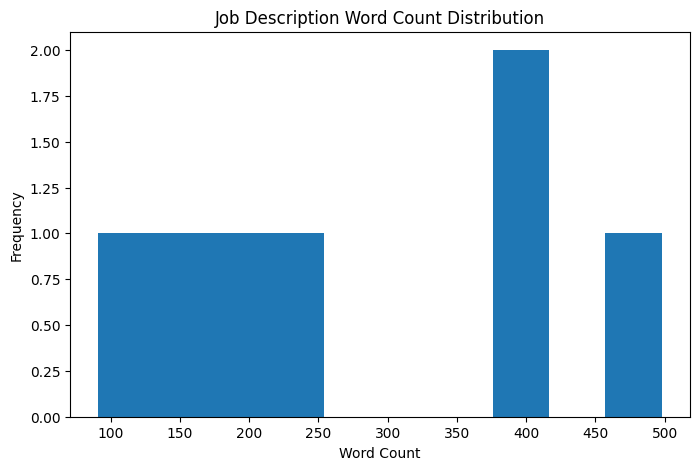

In [43]:
plt.figure(figsize=(8,5))

plt.hist(job_lengths)

plt.title("Job Description Word Count Distribution")

plt.xlabel("Word Count")

plt.ylabel("Frequency")

plt.show()

# STEP 5 : 🤖 TF-IDF Vectorization

This step converts text data into numerical vectors using TF-IDF.

In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer

documents = clean_cvs + clean_jobs

vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2)
)

tfidf_matrix = vectorizer.fit_transform(documents)

print(tfidf_matrix.shape)

(353, 143793)


# STEP 6:  🔍 Cosine Similarity Calculation

This step calculates similarity scores between resumes and job descriptions using cosine similarity.

In [51]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(
    tfidf_matrix[:len(clean_cvs)],
    tfidf_matrix[len(clean_cvs):]
)

print(similarity_matrix)

[[0.0754529  0.04073282 0.02159187 ... 0.0209094  0.01417865 0.04098299]
 [0.08309346 0.02338633 0.02303849 ... 0.01618119 0.01348207 0.0218556 ]
 [0.03899858 0.01848796 0.0375144  ... 0.01168103 0.01025401 0.02293339]
 ...
 [0.00874552 0.00891686 0.00460957 ... 0.01446677 0.01948218 0.06647843]
 [0.01044619 0.00651836 0.01109251 ... 0.01626296 0.01255616 0.03380414]
 [0.02444089 0.01565381 0.03903333 ... 0.03080097 0.01949009 0.03189132]]


In [52]:
print("Similarity Score:")

print(similarity_matrix[0][0] * 100)

Similarity Score:
7.5452904562459455


In [53]:
job_index = 0

scores = similarity_matrix[:, job_index]

for i, score in enumerate(scores):

    print(f"Resume {i+1}: {score * 100:.2f}% Match")

Resume 1: 7.55% Match
Resume 2: 8.31% Match
Resume 3: 3.90% Match
Resume 4: 6.28% Match
Resume 5: 7.57% Match
Resume 6: 4.03% Match
Resume 7: 6.78% Match
Resume 8: 3.46% Match
Resume 9: 7.91% Match
Resume 10: 11.34% Match
Resume 11: 2.99% Match
Resume 12: 8.88% Match
Resume 13: 7.38% Match
Resume 14: 8.58% Match
Resume 15: 1.65% Match
Resume 16: 2.56% Match
Resume 17: 3.64% Match
Resume 18: 1.57% Match
Resume 19: 2.55% Match
Resume 20: 3.05% Match
Resume 21: 2.01% Match
Resume 22: 3.36% Match
Resume 23: 3.15% Match
Resume 24: 3.02% Match
Resume 25: 4.39% Match
Resume 26: 4.08% Match
Resume 27: 2.53% Match
Resume 28: 3.02% Match
Resume 29: 2.10% Match
Resume 30: 2.70% Match
Resume 31: 3.94% Match
Resume 32: 4.14% Match
Resume 33: 2.84% Match
Resume 34: 4.63% Match
Resume 35: 2.06% Match
Resume 36: 3.44% Match
Resume 37: 2.77% Match
Resume 38: 4.49% Match
Resume 39: 2.60% Match
Resume 40: 4.41% Match
Resume 41: 3.08% Match
Resume 42: 3.36% Match
Resume 43: 4.29% Match
Resume 44: 3.46% Ma

# STEP 7 :🧠 Skill Extraction

This step extracts important skills from resumes and job descriptions.

The extracted skills help improve:
- Resume matching
- Skill gap analysis
- Recommendation generation

In [54]:
skills_list = [
    "python",
    "java",
    "sql",
    "machine learning",
    "data analysis",
    "communication",
    "leadership",
    "deep learning",
    "excel",
    "teamwork",
    "problem solving",
    "project management",
    "artificial intelligence",
    "accounting",
    "financial analysis"
]

## 7: 1🔍 Extract Skills Function

This function searches for skills inside the text data.

In [57]:
def extract_skills(text, skills):

    found_skills = []

    for skill in skills:

        if skill.lower() in text.lower():

            found_skills.append(skill)

    return found_skills
print(extract_skills(clean_cvs[0], skills_list))

['communication', 'leadership', 'excel', 'accounting']


## 7:2 📄 Extract Skills from Resume

In [61]:
for i, cv in enumerate(clean_cvs):

    skills = extract_skills(cv, skills_list)

    print(f"\nResume {i+1} Skills:")

    print(skills)


Resume 1 Skills:
['communication', 'leadership', 'excel', 'accounting']

Resume 2 Skills:
['excel', 'problem solving', 'accounting']

Resume 3 Skills:
['communication', 'excel']

Resume 4 Skills:
['excel', 'accounting']

Resume 5 Skills:
['sql', 'communication', 'excel', 'accounting']

Resume 6 Skills:
['communication', 'leadership', 'excel', 'problem solving', 'accounting', 'financial analysis']

Resume 7 Skills:
['excel', 'accounting']

Resume 8 Skills:
['communication', 'leadership', 'teamwork', 'accounting']

Resume 9 Skills:
['communication', 'excel', 'accounting']

Resume 10 Skills:
['communication', 'excel', 'accounting', 'financial analysis']

Resume 11 Skills:
['excel', 'project management', 'accounting']

Resume 12 Skills:
['leadership', 'excel', 'accounting', 'financial analysis']

Resume 13 Skills:
['excel', 'accounting']

Resume 14 Skills:
['excel', 'accounting']

Resume 15 Skills:
['excel']

Resume 16 Skills:
['communication', 'leadership', 'excel']

Resume 17 Skills:
['

In [62]:
from collections import Counter

In [63]:
all_skills = []

for cv in clean_cvs:

    skills = extract_skills(cv, skills_list)

    all_skills.extend(skills)

skill_counts = Counter(all_skills)

print(skill_counts)

Counter({'communication': 232, 'excel': 220, 'leadership': 149, 'project management': 95, 'problem solving': 62, 'accounting': 56, 'sql': 55, 'data analysis': 25, 'teamwork': 23, 'java': 18, 'python': 7, 'financial analysis': 4})


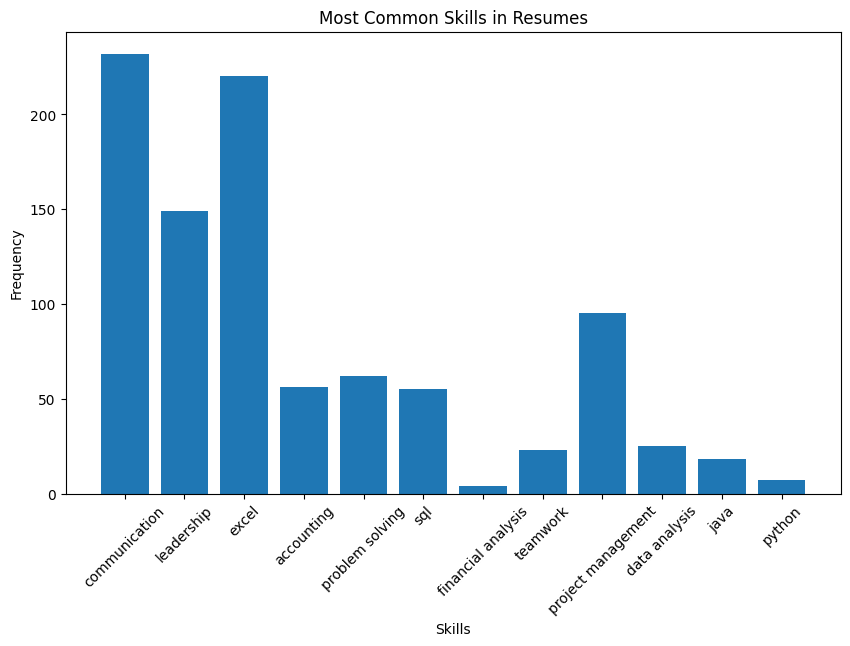

In [64]:
import matplotlib.pyplot as plt

skills = list(skill_counts.keys())

counts = list(skill_counts.values())

plt.figure(figsize=(10,6))

plt.bar(skills, counts)

plt.title("Most Common Skills in Resumes")

plt.xlabel("Skills")

plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

# STEP 8: 🚨 Skill Gap Analysis

This step identifies missing skills by comparing resume skills with job description skills.

In [68]:
resume_skills = extract_skills(clean_cvs[0], skills_list)

job_skills = extract_skills(clean_jobs[0], skills_list)
print("Resume Skills:", resume_skills)

Resume Skills: ['communication', 'leadership', 'excel', 'accounting']


In [66]:
missing_skills = set(job_skills) - set(resume_skills)

print("Missing Skills:\n")

print(missing_skills)

Missing Skills:

{'financial analysis'}


In [69]:
resume_skills = extract_skills(clean_cvs[6], skills_list)

job_skills = extract_skills(clean_jobs[6], skills_list)

In [70]:
missing_skills = set(job_skills) - set(resume_skills)

print("Missing Skills:\n")

print(missing_skills)

Missing Skills:

{'communication'}


In [71]:
resume_skills = extract_skills(clean_cvs[4], skills_list)

job_skills = extract_skills(clean_jobs[4], skills_list)

In [72]:
missing_skills = set(job_skills) - set(resume_skills)

print("Missing Skills:\n")

print(missing_skills)

Missing Skills:

{'leadership'}


# STEP 9: 💡 Resume Improvement Recommendations

This step generates recommendations based on missing skills.

In [73]:
if len(missing_skills) > 0:

    print("Recommended Skills to Add:\n")

    for skill in missing_skills:

        print("-", skill)

else:

    print("The resume matches the job requirements well.")

Recommended Skills to Add:

- leadership


# 9: 1🚨 Full Resume and Job Description Skill Gap Analysis

This step compares all job descriptions with all resumes and identifies missing skills for each comparison.

In [74]:
for j, job in enumerate(clean_jobs):

    print(f"\n==============================")
    print(f"Job Description {j+1}")
    print(f"==============================")

    job_skills = extract_skills(job, skills_list)

    print("\nRequired Skills:")
    print(job_skills)

    for i, cv in enumerate(clean_cvs):

        resume_skills = extract_skills(cv, skills_list)

        missing_skills = set(job_skills) - set(resume_skills)

        print(f"\nResume {i+1}")

        print("Resume Skills:")
        print(resume_skills)

        print("Missing Skills:")

        if missing_skills:

            for skill in missing_skills:

                print("-", skill)

        else:

            print("No missing skills")


Job Description 1

Required Skills:
['excel', 'accounting', 'financial analysis']

Resume 1
Resume Skills:
['communication', 'leadership', 'excel', 'accounting']
Missing Skills:
- financial analysis

Resume 2
Resume Skills:
['excel', 'problem solving', 'accounting']
Missing Skills:
- financial analysis

Resume 3
Resume Skills:
['communication', 'excel']
Missing Skills:
- financial analysis
- accounting

Resume 4
Resume Skills:
['excel', 'accounting']
Missing Skills:
- financial analysis

Resume 5
Resume Skills:
['sql', 'communication', 'excel', 'accounting']
Missing Skills:
- financial analysis

Resume 6
Resume Skills:
['communication', 'leadership', 'excel', 'problem solving', 'accounting', 'financial analysis']
Missing Skills:
No missing skills

Resume 7
Resume Skills:
['excel', 'accounting']
Missing Skills:
- financial analysis

Resume 8
Resume Skills:
['communication', 'leadership', 'teamwork', 'accounting']
Missing Skills:
- financial analysis
- excel

Resume 9
Resume Skills:
['c

# THE END>>>

# ✅ Preprocessing Conclusion

In this stage, the dataset was successfully prepared for analysis and processing.

The preprocessing pipeline included:
- Loading resume and job description files
- Extracting textual data from PDF and TXT files
- Cleaning and standardizing text data
- Removing punctuation, numbers, and stopwords
- Converting text to lowercase

These preprocessing steps improved data quality and prepared the dataset for:
- Text analysis
- Skill extraction
- Similarity matching
- AI-based recommendation systems